Importing Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import html
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

#Scikit-learn tools
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

# Models
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier

# Model saving or loading
import joblib

# Deployment & Testing
from flask import Flask, request, jsonify
import requests
import threading

# Explainability
!pip install lime -q
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LAP-49\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LAP-49\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LAP-49\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


All libraries imported successfully


Loading Data

In [2]:
data_path = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\fake_job_postings.csv"
print('Exists :', os.path.exists(data_path))

Exists : True


In [3]:
data = pd.read_csv(data_path)
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


EDA

In [4]:
data.shape

(17880, 18)

In [5]:
data.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [6]:
data.dtypes

job_id                 int64
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting          int64
has_company_logo       int64
has_questions          int64
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

In [7]:
data.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [9]:
data.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [10]:
data['location'] = data['location'].fillna('unknown')

In [11]:
data['location'].value_counts()

location
GB, LND, London             718
US, NY, New York            658
US, CA, San Francisco       472
GR, I, Athens               464
unknown                     346
                           ... 
US, NJ, Berkeley Heights      1
DE, BE, berlin                1
US, CA, los Angeles           1
CA, , Ottawa                  1
GB, WSX, Chichester           1
Name: count, Length: 3106, dtype: int64

In [12]:
data['country'] = data['location'].str.split(',').str[0].str.strip()

In [13]:
data.iloc[343:346]

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country
343,344,Quality Assurance (QA) Engineer,"GR, I, Neo Iraklio, Athens",Solution Test,0-1000,Unify — formerly known as Siemens Enterprise C...,"Develop Test plans, Regression Test plans for ...","Education, Experience &amp; Profile:BS/MS in C...",Competitive remuneration packagePrivate insura...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Telecommunications,Quality Assurance,0,GR
344,345,Graduates: English Teacher Abroad,"US, PA, Pittsburgh",NaN,NaN,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it :-)Love travel...",University degree required. TEFL / TESOL / CEL...,See job description,0,1,0,Contract,NaN,Bachelor's Degree,Education Management,NaN,0,US
345,346,Kindergarten Teacher,"RU, MOW, Moscow",NaN,36000-40000,"We place highly qualified governors, governess...",A Russian school in the south of Moscow are l...,- All applicants should be currently living in...,- The working hours would be 9-5 Mon-Fri. - Ca...,0,1,0,Full-time,Not Applicable,Unspecified,Primary/Secondary Education,Education,0,RU


In [14]:
data['country'].value_counts()[:10]

country
US         10656
GB          2384
GR           940
CA           457
DE           383
unknown      346
NZ           333
IN           276
AU           214
PH           132
Name: count, dtype: int64

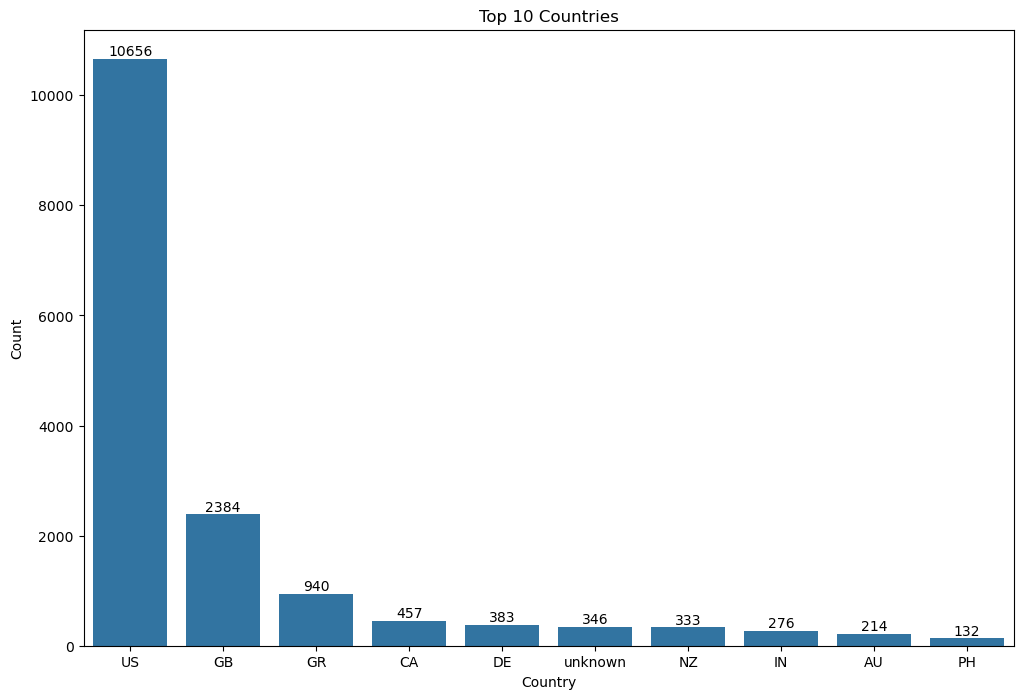

In [15]:
c = data['country'].value_counts()[:10]

plt.figure(figsize = (12,8))
ax = sns.barplot(x = c.index, y = c.values)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries')

for i, v in enumerate(c.values):
  ax.text(i, v+5, str(v), ha = 'center', va = 'bottom', fontsize = 10)

plt.show()

In [16]:
data['department'] = data['department'].fillna('unspecified')

In [17]:
data.isnull().sum()

job_id                     0
title                      0
location                   0
department                 0
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
country                    0
dtype: int64

In [18]:
d = data['department'].value_counts()
d

department
unspecified            11547
Sales                    551
Engineering              487
Marketing                401
Operations               270
                       ...  
ADMIN                      1
Customer service           1
Admin - Clerical           1
Administrative Dept        1
Hospitality                1
Name: count, Length: 1338, dtype: int64

In [19]:
len(d)

1338

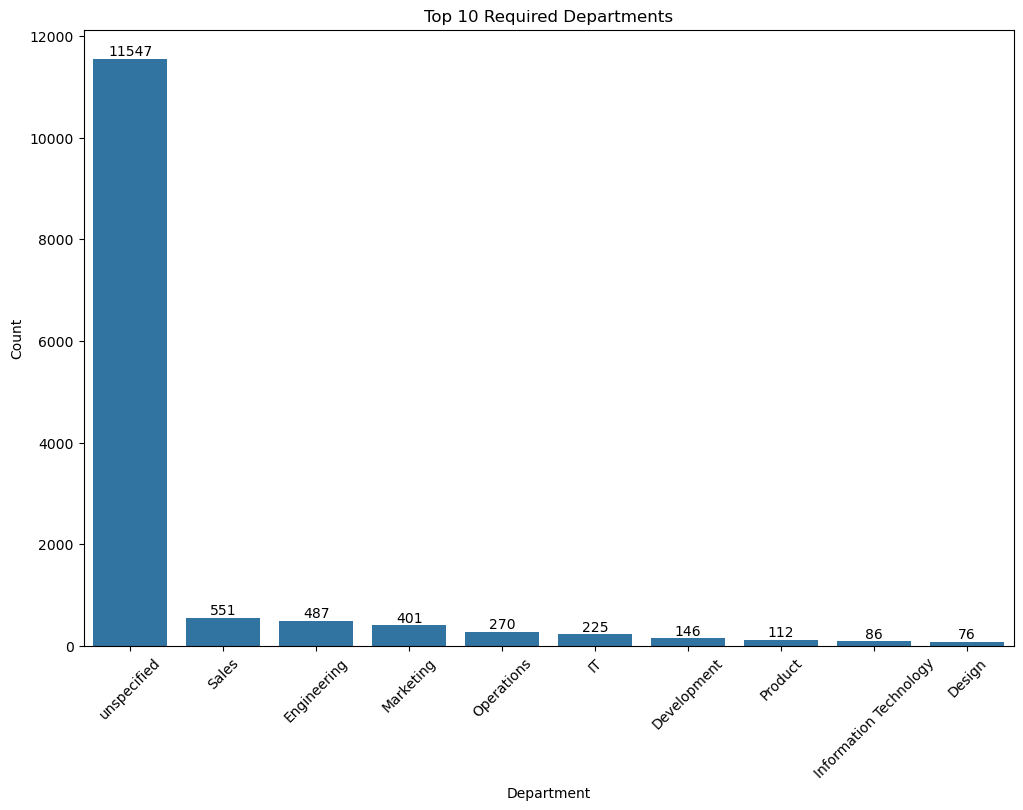

In [20]:
d = data['department'].value_counts()[:10]

plt.figure(figsize = (12,8))
ax = sns.barplot(x = d.index, y = d.values)
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.title('Top 10 Required Departments')

for i, v in enumerate(d.values):
  ax.text(i, v+5, str(v), ha = 'center', va = 'bottom', fontsize = 10)

plt.show()

In [21]:
data['salary_range'].unique()

<StringArray>
[            nan,   '20000-28000', '100000-120000', '120000-150000',
   '50000-65000',   '40000-50000',         '60-80',   '65000-70000',
        '75-115',  '75000-110000',
 ...
        'Dec-25',     '1517-1517',    '1234-12345',   '34000-42000',
         '15-19',         '21-31',   '48000-65000',   '53000-67000',
      '22-61000',     '3700-3800']
Length: 875, dtype: str

In [22]:
s = pd.Series(data['salary_range'].dropna().unique())
x = s.str.contains(r'[a-zA-z]', na = False)
print(x.sum())
print(s[x].tolist())

15
['9-Dec', '3-Apr', '4-Apr', 'Oct-15', '8-Sep', '4-Jun', '10-Oct', 'Oct-20', 'Jun-18', '11-Nov', '10-Nov', '11-Dec', '2-Apr', '2-Jun', 'Dec-25']


In [23]:
data['telecommuting'].unique()

array([0, 1])

In [24]:
data['telecommuting'].value_counts()

telecommuting
0    17113
1      767
Name: count, dtype: int64

In [25]:
for col in ['telecommuting', 'has_company_logo', 'has_questions']:
  print(col, data[col].unique())

telecommuting [0 1]
has_company_logo [1 0]
has_questions [0 1]


In [26]:
for col in ['telecommuting', 'has_company_logo', 'has_questions']:
  print(data[col].value_counts())

telecommuting
0    17113
1      767
Name: count, dtype: int64
has_company_logo
1    14220
0     3660
Name: count, dtype: int64
has_questions
0    9088
1    8792
Name: count, dtype: int64


In [27]:
data.drop(['job_id', 'salary_range','telecommuting', 'has_company_logo', 'has_questions'], axis = 1, inplace = True)

In [28]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent,country
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,Other,Internship,NaN,NaN,Marketing,0,US
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,NZ
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unspecified,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,NaN,NaN,NaN,NaN,NaN,0,US
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US
4,Bill Review Manager,"US, FL, Fort Worth",unspecified,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US


In [29]:
cols = ['company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
data[cols] = data[cols].astype('object')
data[cols] = data[cols].fillna('unspecified')

In [30]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent,country
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,unspecified,Other,Internship,unspecified,unspecified,Marketing,0,US
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,unspecified,Marketing and Advertising,Customer Service,0,NZ
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unspecified,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,unspecified,unspecified,unspecified,unspecified,unspecified,unspecified,0,US
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US
4,Bill Review Manager,"US, FL, Fort Worth",unspecified,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US


In [31]:
data.isnull().sum()

title                  0
location               0
department             0
company_profile        0
description            0
requirements           0
benefits               0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
country                0
dtype: int64

In [32]:
data.duplicated().sum()

np.int64(299)

In [33]:
data = data.drop_duplicates()

In [34]:
data.duplicated().sum()

np.int64(0)

In [35]:
data['fraudulent'].value_counts(normalize=True) * 100

fraudulent
0    95.136795
1     4.863205
Name: proportion, dtype: float64

In [36]:
data.shape

(17581, 14)

Text Preprocessing

Preparing stopwords list

In [37]:
stop_words = set(stopwords.words('english'))
print('Stop words are ready. Example :', list(stop_words)[:5])

Stop words are ready. Example : ['again', 'll', 'having', 'than', 'wouldn']


Defining the Cleaning Function

In [38]:
# List text columns
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# Count URLs per column
url_counts = {col: data[col].str.contains('http', case=False, na=False).sum() for col in text_columns}
print("URLs found per column:", url_counts)
print("Total rows with any URL:", data[text_columns].apply(lambda row: row.str.contains('http', case=False, na=False).any(), axis=1).sum())

URLs found per column: {'title': np.int64(0), 'company_profile': np.int64(87), 'description': np.int64(94), 'requirements': np.int64(135), 'benefits': np.int64(29)}
Total rows with any URL: 307


In [39]:
# Find first row with URL in 'description' (or any column)
sample_url_row = data[data['description'].str.contains('http', case=False, na=False)]['description'].head(5)
if not sample_url_row.empty:
    print("Sample text with URL:", sample_url_row.iloc[4])
else:
    print("No URLs found!")

Sample text with URL: #URL_ab309fb672a2b26317bd303c09c3c6762986d45c2bb1b4970cac579d697432e2# is hiring current college students and recent graduates!  You must be digitally savvy and able to get things done on time!#URL_ab309fb672a2b26317bd303c09c3c6762986d45c2bb1b4970cac579d697432e2#’s mission is simple: to connect students and companies with new opportunities to get projects and tasks done.  You can become a remote intern with amazing companies, while earning money too. The best part? You get the chance to impress companies so much that they might make you a job offer – we offer every company we work with the opportunity to interview our interns for a full time position if you knock it out of the park. We don’t want you to intern with us forever – we’d rather you get a full time gig and then hire one of our interns to help you out!As an intern for #URL_ab309fb672a2b26317bd303c09c3c6762986d45c2bb1b4970cac579d697432e2#, you build your portfolio while doing real projects for real compan

In [40]:
# Lemmatizer - reduces the words to their base form using vocabulary and grammar rules
lem = WordNetLemmatizer()
print("Lemmatizer is ready. Example: lem.lemmatize('running') = ", lem.lemmatize('played', pos = 'v'))

Lemmatizer is ready. Example: lem.lemmatize('running') =  play


In [41]:
lem = WordNetLemmatizer()

print("running   →", lem.lemmatize('running', pos = 'v'))      
print("played    →", lem.lemmatize('played', pos='v'))       
print("better    →", lem.lemmatize('better', pos='a'))       
print("children  →", lem.lemmatize('children', pos='n'))    
print("went      →", lem.lemmatize('went', pos='v'))        
print("mice      →", lem.lemmatize('mice', pos='n'))      

running   → run
played    → play
better    → good
children  → child
went      → go
mice      → mouse


In [42]:
# Text cleaning
def text_clean(text):
    if not isinstance(text, str):
        text = str(text)
    
    text = html.unescape(text)
    text = text.lower()
    
    # Keeping important scam words and numbers
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)   # Keeping words and spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # lemmatization
    words = [lem.lemmatize(word, pos='v') for word in words]
    
    return ' '.join(words)

In [43]:
print('Before cleaning :', sample_url_row.iloc[3])
print('After cleaning :', text_clean(sample_url_row.iloc[3]))

Before cleaning : We are currently recruiting for an exciting Sales &amp; Customer Service role. We are looking for someone with a passion for sales, beauty and fragrance who is enthusiastic and driven.The ideal candidates will have the ability to demonstrate a fresh approach to sales and be able to work in a fast paced and versatile environment.If you are looking to build your career in Beauty, Promotional work, Sales and Customer Service apply now.The role would suit anyone with the following experience:* Great communication skills* Positive attitude* Be able to hit targets and achieve goals* Be able to work in a customer facing role* The ability to build and maintain strong relationships with clients and customers* Beauty training or make up artisty* Fragrance or cosmetic counter experienceFull product training will be available to all successful candidates.Please click on the link below to apply directlyhttps://b4.#URL_c050d78cefc5b9fd74edaf55bf1e65eb99b3be8c37df0cbef9b053604be1ce8

In [44]:
# Cleaning Textual data
text_col = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in text_col:
  data[col] = data[col].apply(text_clean)

print('Cleaning applied to all text columns')

Cleaning applied to all text columns


In [45]:
# Combining multiple text columns into a single string column
data['combined_text'] = data[text_columns].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
print("Combined text sample (first row):", data['combined_text'].iloc[0][:200] + "...")  # Shortened

Combined text sample (first row): market intern food52 create groundbreaking award win cook site support connect celebrate home cook give everything need one place top editorial business engineer team focus use technology find new bet...


In [46]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent,country,combined_text
0,market intern,"US, NY, New York",Marketing,food52 create groundbreaking award win cook si...,food52 fast grow jam beard award win online fo...,experience content management systems major pl...,unspecified,Other,Internship,unspecified,unspecified,Marketing,0,US,market intern food52 create groundbreaking awa...
1,customer service cloud video production,"NZ, , Auckland",Success,90 second worlds cloud video production servic...,organise focus vibrant awesome passion custome...,expect key responsibility communicate client 9...,get usthrough part 90 second team gain experie...,Full-time,Not Applicable,unspecified,Marketing and Advertising,Customer Service,0,NZ,customer service cloud video production 90 sec...
2,commission machinery assistant cma,"US, IA, Wever",unspecified,valor service provide workforce solutions meet...,client locate houston actively seek experience...,implement pre commission commission procedures...,unspecified,unspecified,unspecified,unspecified,unspecified,unspecified,0,US,commission machinery assistant cma valor servi...
3,account executive washington dc,"US, DC, Washington",Sales,passion improve quality life geography heart e...,company esri environmental systems research in...,education bachelor master gi business administ...,culture anything corporate collaborative creat...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,account executive washington dc passion improv...
4,bill review manager,"US, FL, Fort Worth",unspecified,spotsource solutions llc global human capital ...,job title itemization review managerlocation f...,qualifications rn license state texasdiploma b...,full benefit offer,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,bill review manager spotsource solutions llc g...


In [47]:
print("Combined text sample (first row):", data['combined_text'].iloc[54][:200] + "...")  # Shortened

Combined text sample (first row): outside sales professional st cloud abc supply co inc nation largest wholesale distributor roof one largest distributors side windows exterior build products since start 1982 grow become national orga...


Feature Extraction

Encoding Categorical variables

In [48]:
data.head(3)

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent,country,combined_text
0,market intern,"US, NY, New York",Marketing,food52 create groundbreaking award win cook si...,food52 fast grow jam beard award win online fo...,experience content management systems major pl...,unspecified,Other,Internship,unspecified,unspecified,Marketing,0,US,market intern food52 create groundbreaking awa...
1,customer service cloud video production,"NZ, , Auckland",Success,90 second worlds cloud video production servic...,organise focus vibrant awesome passion custome...,expect key responsibility communicate client 9...,get usthrough part 90 second team gain experie...,Full-time,Not Applicable,unspecified,Marketing and Advertising,Customer Service,0,NZ,customer service cloud video production 90 sec...
2,commission machinery assistant cma,"US, IA, Wever",unspecified,valor service provide workforce solutions meet...,client locate houston actively seek experience...,implement pre commission commission procedures...,unspecified,unspecified,unspecified,unspecified,unspecified,unspecified,0,US,commission machinery assistant cma valor servi...


Initializing OneHotEncoder for encoding categorical features

In [49]:
categorical_columns = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country']

enc = OneHotEncoder(sparse_output = True, handle_unknown = 'ignore')
print('Encoder is ready.')

Encoder is ready.


In [50]:
enc.fit(data[categorical_columns])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

In [51]:
# Saving the trained encoder
enc_path = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\onehot_encoder.pkl"
joblib.dump(enc, enc_path)
print(f'Trained encoder saved successully as onehot_encoder.pkl in {enc_path}')

Trained encoder saved successully as onehot_encoder.pkl in C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\onehot_encoder.pkl


In [52]:
# Transforming categorical columns into one-hot encoded sparse matrix
x_cat = enc.transform(data[categorical_columns])
print('Encoded categoricals shape :', x_cat.shape)

Encoded categoricals shape : (17581, 1627)


In [53]:
# Checking a sample
sample_dense = x_cat[0].toarray() if hasattr(x_cat, 'toarray') else x_cat[0]
print('Sample encoded first row (partial):', sample_dense[0][:10])

Sample encoded first row (partial): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


TF-IDF Vectorizer

In [54]:
# # Highlighting 5000 important words in text for ML
vectorizer = TfidfVectorizer(max_features=5000)
print('TF-IDF vectorizer Ready')

TF-IDF vectorizer Ready


In [55]:
# Learning patterns from text to build vocabulary model
vectorizer.fit(data['combined_text'])
print('Vectorizer fitted successfully')

Vectorizer fitted successfully


In [56]:
# Saving the trained vectorizer
vec_path = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\TF-IDF_vectorizer.pkl"
joblib.dump(vectorizer, vec_path)
print(f'Trained vectorizer saved successfully as TF-IDF_vectorizer.pkl in {vec_path}')

Trained vectorizer saved successfully as TF-IDF_vectorizer.pkl in C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\TF-IDF_vectorizer.pkl


In [57]:
# Converting text into numeric features for ML analysis
x_text = vectorizer.transform(data['combined_text'])
print('Text Features shape :', x_text.shape)

Text Features shape : (17581, 5000)


In [58]:
# Combining text and categorical columns
X = hstack([x_text, x_cat])
print('Final Features shape :', X.shape)
print('\nSample first row (dense partial):', X[0].toarray()[0][:10])

Final Features shape : (17581, 6627)

Sample first row (dense partial): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [59]:
# Extracting labels and checking class balance
y = data['fraudulent']
print('Labels shape:', y.shape)
print('Class imbalance in full y:', y.value_counts(normalize=True) * 100)

Labels shape: (17581,)
Class imbalance in full y: fraudulent
0    95.136795
1     4.863205
Name: proportion, dtype: float64


In [60]:
# Splitting data into training and testing sets for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print('Train shapes :', X_train.shape, y_train.shape)
print('Test shapes :', X_test.shape, y_test.shape)

Train shapes : (14064, 6627) (14064,)
Test shapes : (3517, 6627) (3517,)


In [61]:
# Saving the training and test feature sets
X_train_path = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\X_train.pkl"
joblib.dump(X_train, X_train_path)
print(f'X_train saved successully to {X_train_path}')

X_test_path = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\X_test.pkl"
joblib.dump(X_test, X_test_path)
print(f'X_test saved successully to {X_test_path}')

X_train saved successully to C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\X_train.pkl
X_test saved successully to C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\X_test.pkl


In [62]:
# Checking class distribution in train and test sets
print('Train class balance:', y_train.value_counts(normalize=True) * 100)
print('Test class balance:', y_test.value_counts(normalize=True) * 100)

Train class balance: fraudulent
0    95.136519
1     4.863481
Name: proportion, dtype: float64
Test class balance: fraudulent
0    95.137902
1     4.862098
Name: proportion, dtype: float64


Model Building

***1.Logistic Regression***

In [63]:
# Logistic Regression model building
lr_mod = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
print('Logistic Regression model ready.')

Logistic Regression model ready.


*Hyperparameter Tuning*

In [64]:
# Defining SVM hyperparameter grid and setting up GridSearch for tuning
param_grid = param_grid_lr = {'C': [0.01, 0.1, 1, 10, 50]}      # Wider range for better tuning

grid_lr = GridSearchCV(lr_mod, param_grid, cv = 3, scoring = 'f1', n_jobs = -1, verbose = 1)
print('Tuning Grid is ready.')

Tuning Grid is ready.


In [65]:
# Loading tuned LR model if available
lr_file = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\best_lr_tuned_model.pkl"

# Else performing hyperparameter tuning and saving best model
if os.path.exists(lr_file):
    best_lr = joblib.load(lr_file)
    print('Logistic Regression model loaded from file.')
else:
    print('Starting tuning for Logistic Regression...')
    grid_lr.fit(X_train, y_train)
    print('Best params:', grid_lr.best_params_)
    print('Best CV F1 score:', grid_lr.best_score_)
    best_lr = grid_lr.best_estimator_
    joblib.dump(best_lr, lr_file)
    print('Tuned and saved Logistic Regression model')

Logistic Regression model loaded from file.


*Predicting with best LR*

In [66]:
# Predicting with Best Logistic Regression model
y_pred_lr = best_lr.predict(X_test)

print('Sample first 5 predictions:', y_pred_lr[:5])
print('Predicted class balance:\n', 
      pd.Series(y_pred_lr).value_counts(normalize=True) * 100)

Sample first 5 predictions: [0 0 0 0 0]
Predicted class balance:
 0    95.223202
1     4.776798
Name: proportion, dtype: float64


*Evaluation for tuned LR*

In [67]:
# Checking the accuracy, precision, recall, F1 scores
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

#Full report
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))

Accuracy: 0.982087005970998
Precision: 0.8214285714285714
Recall: 0.8070175438596491
F1 Score: 0.8141592920353983

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3346
           1       0.82      0.81      0.81       171

    accuracy                           0.98      3517
   macro avg       0.91      0.90      0.90      3517
weighted avg       0.98      0.98      0.98      3517



*Confusion Matrix for tuned LR*

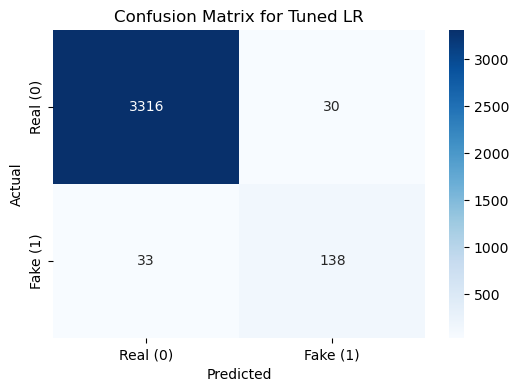

In [68]:
# Visualizing the performance of the LR using confusion matrix.
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = ['Real (0)', 'Fake (1)'], yticklabels = ['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned LR')
plt.show()

***2.Support Vector Machine***

In [69]:
# SVM Model building
svm_mod = SVC(class_weight = 'balanced', probability = True, random_state = 42)
print('SVM model ready.')

SVM model ready.


*Hyperparameter Tuning*

In [70]:
# Defining SVM hyperparameter grid and setting up GridSearch for tuning
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 50]},                    # 2 options – fast
    {'kernel': ['rbf'], 'C': [1, 10, 50], 'gamma': ['scale', 0.01, 0.1]}  # 4 options – reasonable
]

grid_svm = GridSearchCV(svm_mod, param_grid_svm, cv = 3, scoring = 'f1', n_jobs =  -1, verbose = 1)
print('Tuning grid is ready')

Tuning grid is ready


In [71]:
# Loading tuned SVM model if available
svm_file = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\best_svm_tuned_model.pkl"

if os.path.exists(svm_file):
  best_svm = joblib.load(svm_file)
  print('SVM model loaded from file.')

# Else performing hyperparameter tuning and saving best model
else:
  print('Starting  tuning...')
  grid_svm.fit(X_train, y_train)
  print('Best params:', grid_svm.best_params_)
  print('Best CV F1 score:', grid_svm.best_score_)
  best_svm = grid_svm.best_estimator_
  joblib.dump(best_svm, svm_file)
  print('Tuned and saved SVM model')

SVM model loaded from file.


*Predicting with best SVM*

In [72]:
# Predicting with Best SVM model
y_pred_svm = best_svm.predict(X_test)

print('Sample first 5 predictions:', y_pred_svm[:5])
print('SVM predicted class balance:', pd.Series(y_pred_svm).value_counts(normalize=True) * 100)

Sample first 5 predictions: [0 0 0 0 0]
SVM predicted class balance: 0    96.189935
1     3.810065
Name: proportion, dtype: float64


*Evaluation for tuned SVM*

In [73]:
# Checking the accuracy, precision, recall, F1 scores
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print('SVM Accuracy:', accuracy_svm)
print('SVM Precision:', precision_svm)
print('SVM Recall:', recall_svm)
print('SVM F1 Score:', f1_svm)

print('\nSVM classification Report:\n', classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9860676713107762
SVM Precision: 0.9552238805970149
SVM Recall: 0.7485380116959064
SVM F1 Score: 0.839344262295082

SVM classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3346
           1       0.96      0.75      0.84       171

    accuracy                           0.99      3517
   macro avg       0.97      0.87      0.92      3517
weighted avg       0.99      0.99      0.99      3517



*Confusion Matrix for tuned SVM*

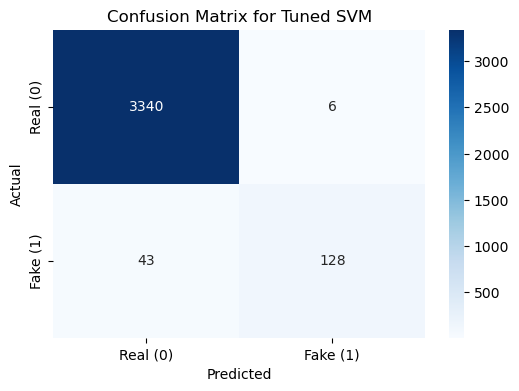

In [74]:
# Visualizing the performance of the SVM using confusion matrix. 
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Real (0)', 'Fake (1)'], yticklabels = ['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned SVM')
plt.show()

***3.XGBoost (Gradient Boosting)***

In [75]:
xgb_mod = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])  # Handle imbalance
)

*Hyperparameter Tuning*

In [76]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb_mod, 
    param_grid_xgb, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print('Tuning grid is ready')

Tuning grid is ready


In [77]:
# Loading tuned XGB model if available
xgb_file = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning\best_xgb_tuned_model.pkl"

if os.path.exists(xgb_file):
    best_xgb = joblib.load(xgb_file)
    print('XGBoost model loaded from file.')

# Else performing hyperparameter tuning and saving best model
else:
    print('Starting tuning... This may take some time.')
    grid_xgb.fit(X_train, y_train)
    print('Best params:', grid_xgb.best_params_)
    print('Best CV F1 score:', grid_xgb.best_score_)
    best_xgb = grid_xgb.best_estimator_
    joblib.dump(best_xgb, xgb_file)
    print('Tuned and saved XGBoost model')

print("XGBoost training completed.")

XGBoost model loaded from file.
XGBoost training completed.


*Predicting with best XGBoosting*

In [78]:
y_pred_xgb = best_xgb.predict(X_test)

print('Sample first 5 XGBoost predictions:', y_pred_xgb[:5])
print('XGBoost predicted class balance:', pd.Series(y_pred_xgb).value_counts(normalize=True) * 100)

Sample first 5 XGBoost predictions: [0 0 0 0 0]
XGBoost predicted class balance: 0    95.649701
1     4.350299
Name: proportion, dtype: float64


*Evaluation for tuned XGBoosting*

In [79]:
# Checking the accuracy, precision, recall, F1 scores
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print('XGBoosting Accuracy:', accuracy_xgb)
print('XGBoosting Precision:', precision_xgb)
print('XGBoosting Recall:', recall_xgb)
print('XGBoosting F1 Score:', f1_xgb)

print('\nXGBoosting classification Report:\n', classification_report(y_test, y_pred_xgb))

XGBoosting Accuracy: 0.9835086721637759
XGBoosting Precision: 0.869281045751634
XGBoosting Recall: 0.7777777777777778
XGBoosting F1 Score: 0.8209876543209876

XGBoosting classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3346
           1       0.87      0.78      0.82       171

    accuracy                           0.98      3517
   macro avg       0.93      0.89      0.91      3517
weighted avg       0.98      0.98      0.98      3517



*Confusion Matrix for tuned XGBoosting*

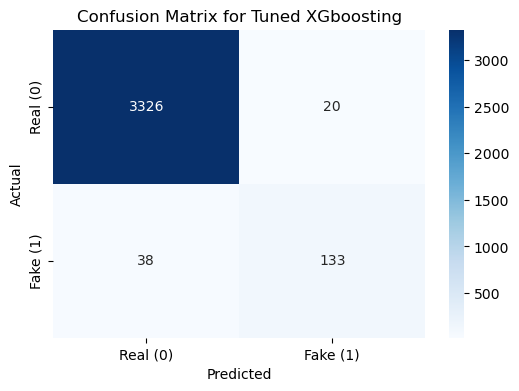

In [80]:
# Visualizing the performance of the XGBoosting using confusion matrix.
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Real (0)', 'Fake (1)'], yticklabels = ['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned XGboosting')
plt.show()

Using ROC-AUC score for final model validation


In [81]:
# To get the probabilities (predict_proba[:, 1] for class 1/fake)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Computing AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print('LR ROC-AUC:', auc_lr)
print('SVM ROC-AUC:', auc_svm)
print('XGBoost ROC-AUC:', auc_xgb)

LR ROC-AUC: 0.973077743172436
SVM ROC-AUC: 0.9816766462879654
XGBoost ROC-AUC: 0.986722384762464


In [82]:
data.info()

<class 'pandas.DataFrame'>
Index: 17581 entries, 0 to 17879
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17581 non-null  str   
 1   location             17581 non-null  str   
 2   department           17581 non-null  str   
 3   company_profile      17581 non-null  str   
 4   description          17581 non-null  str   
 5   requirements         17581 non-null  str   
 6   benefits             17581 non-null  str   
 7   employment_type      17581 non-null  object
 8   required_experience  17581 non-null  object
 9   required_education   17581 non-null  object
 10  industry             17581 non-null  object
 11  function             17581 non-null  object
 12  fraudulent           17581 non-null  int64 
 13  country              17581 non-null  object
 14  combined_text        17581 non-null  str   
dtypes: int64(1), object(6), str(8)
memory usage: 2.1+ MB


Prediction and Deployment

In [83]:
def check_test_sample(index, show_true_label=True):
    if not hasattr(X_test, 'shape'):
        print(f"Error: X_test does not have .shape attribute. Check your data type.")
        return
    
    # Get the sample
    n_sample = X_test.shape[0]

    if index < 0 or index >= n_sample:
        print(f"Error: Index {index} is out of range. Use 0 to {n_sample-1}")
        return

    # Getting 1 sample
    X_sample = X_test[index]
    
    # Predict
    pred = best_svm.predict(X_sample)[0]
    prob = best_svm.predict_proba(X_sample)[0][1]  # Fake probability
    
    result = 'Fake' if pred == 1 else 'Real'

    prob_percent = round(prob * 100, 2) if prob >= 0.0001 else 0.00
    
    # Print in your exact format
    print(f"Prediction : {result}")
    print(f"Fake Probability : {prob_percent}%")
    
    # Optional: showing true label
    if show_true_label:
        y_true = y_test.iloc[index] if hasattr(y_test, 'iloc') else y_test[index]
        true_text = 'Fake' if y_true == 1 else 'Real'
        correct = "Correct" if pred == y_true else "Wrong"
        print(f"(True label was: {true_text} – {correct})")

In [84]:
X_test.shape

(3517, 6627)

In [85]:
check_test_sample(123)

Prediction : Real
Fake Probability : 0.04%
(True label was: Real – Correct)


In [86]:
check_test_sample(1331)

Prediction : Real
Fake Probability : 0.93%
(True label was: Real – Correct)


In [87]:
check_test_sample(3517)

Error: Index 3517 is out of range. Use 0 to 3516


In [88]:
check_test_sample(2317)

Prediction : Real
Fake Probability : 0.09%
(True label was: Real – Correct)


In [89]:
check_test_sample(937)

Prediction : Real
Fake Probability : 3.94%
(True label was: Real – Correct)


In [90]:
def predict_new_job(new_job_dict, threshold=0.5):
    """
    Simple prediction function.
    Call it like: predict_new_job(sample_r1)
    """
    # Load everything inside the function (self-contained)
    project_folder = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning"
    
    vectorizer = joblib.load(os.path.join(project_folder, 'TF-IDF_vectorizer.pkl'))
    encoder = joblib.load(os.path.join(project_folder, 'onehot_encoder.pkl'))
    model = joblib.load(os.path.join(project_folder, 'best_svm_tuned_model.pkl'))

    # Cleaning text columns
    for col in text_columns:
        new_job_dict[col] = new_job_dict.get(col, 'unspecified')
        new_job_dict[col] = text_clean(new_job_dict[col])

    # Combining cleaned text
    combined_text = ' '.join(new_job_dict[col] for col in text_columns)

    # Vectorizing text
    X_text_new = vectorizer.transform([combined_text])

    # Encoding categoricals
    cat_df = pd.DataFrame({col: [new_job_dict.get(col, 'unspecified')] for col in categorical_columns})
    X_cat_new = encoder.transform(cat_df)

    # Stacking
    X_new = hstack([X_text_new, X_cat_new])

    # Predicting
    prob = model.predict_proba(X_new)[0][1]
    result = 'Fake' if prob >= threshold else 'Real'

    # Clean percentage
    prob_percent = round(prob * 100, 2)

    print(f"Prediction : {result}")
    print(f"Fake Probability : {prob_percent}%")

    return result, prob_percent

Testing with samples

In [91]:
s = data.iloc[454].to_dict()
for key, value in s.items():
  print(f"'{key}' : \"{value}\",")

'title' : "customer service agent",
'location' : "DE, BY, Munich",
'department' : "non-tech",
'company_profile' : "hello worldtalents23_ drive change digital recruitment develop best quality filter selection top talents",
'description' : "efficient motivate way become athletic anywhere anytime weight machine athletes receive train plan connect compare workout time via app website count 2 000 000 register users around globe thousands every day grow rapidly begin hard work passion awesome team chance life look customer service agent full time headquater munichwe stay touch big fast grow community 2 500 000 members outgo extrovert enjoy communication people across globe team player work reliably pay attention quality work independently remain calm stressful situation responsibilities understand need communitystay touch members around globe via emailbe first point contact members manage communication independentlywork state art community management toolsmanage member accountsimprove user e

In [92]:
sample_r1 = {'title' : "customer service agent",
'location' : "DE, BY, Munich",
'department' : "non-tech",
'company_profile' : "hello worldtalents23_ drive change digital recruitment develop best quality filter selection top talents",
'description' : "efficient motivate way become athletic anywhere anytime weight machine athletes receive train plan connect compare workout time via app website count 2 000 000 register users around globe thousands every day grow rapidly begin hard work passion awesome team chance life look customer service agent full time headquater munichwe stay touch big fast grow community 2 500 000 members outgo extrovert enjoy communication people across globe team player work reliably pay attention quality work independently remain calm stressful situation responsibilities understand need communitystay touch members around globe via emailbe first point contact members manage communication independentlywork state art community management toolsmanage member accountsimprove user experience case query",
'requirements' : "strong communication skillshands approach focus execution get things do mentalityvery quick learn adapt different situationsteam player high commitment motivationfluent two languages excellent oral write communication skills possible combination german spanish portuguese",
'benefits' : "high impact responsibility successful fast grow companya team smart extremely motivate co workersthe chance play crucial role part something really bigself fulfillment fun great atmosphereno wall limit bureaucracy unlimited potentialattractive compensationsocial activities food drink events team train",
'has_company_logo' : "1",
'employment_type' : "Full-time",
'required_experience' : "Associate",
'required_education' : "Bachelor's Degree",
'industry' : "Sports",
'function' : "Customer Service",
'country' : "DE",
'combined_text' : "customer service agent hello worldtalents23_ drive change digital recruitment develop best quality filter selection top talents efficient motivate way become athletic anywhere anytime weight machine athletes receive train plan connect compare workout time via app website count 2 000 000 register users around globe thousands every day grow rapidly begin hard work passion awesome team chance life look customer service agent full time headquater munichwe stay touch big fast grow community 2 500 000 members outgo extrovert enjoy communication people across globe team player work reliably pay attention quality work independently remain calm stressful situation responsibilities understand need communitystay touch members around globe via emailbe first point contact members manage communication independentlywork state art community management toolsmanage member accountsimprove user experience case query strong communication skillshands approach focus execution get things do mentalityvery quick learn adapt different situationsteam player high commitment motivationfluent two languages excellent oral write communication skills possible combination german spanish portuguese high impact responsibility successful fast grow companya team smart extremely motivate co workersthe chance play crucial role part something really bigself fulfillment fun great atmosphereno wall limit bureaucracy unlimited potentialattractive compensationsocial activities food drink events team train",
}

predict_new_job(sample_r1);

Prediction : Real
Fake Probability : 0.11%


In [93]:
sample_f1 = {
'title' : "data entry specialist",
'location' : "US, CA, Remote",
'department' : "non-tech",
'company_profile' : "futuregrowth99_ leading innovation digital platform connect millions worldwide unmatched success story rapid expansion global offices",
'description' : "exciting opportunity join fastest grow company world handle simple data entry task flexible schedule work anywhere anytime earn unlimited income no prior experience require only basic computer knowledge start immediately join awesome team chance life responsibilities include input data system maintain record accuracy communicate supervisor daily update",
'requirements' : "no prior experience require basic computer skill fast internet connectionability work independently strong motivation earn money flexible adapt different situation",
'benefits' : "unlimited earning potential work anywhere anytime fast grow company supportive team environment no limit promotion opportunity fun exciting atmosphere",
'has_company_logo' : "1",
'employment_type' : "Full-time",
'required_experience' : "None",
'required_education' : "High School or None",
'industry' : "Data Services",
'function' : "Data Entry",
'country' : "US",
'combined_text' : "data entry specialist futuregrowth99_ leading innovation digital platform connect millions worldwide unmatched success story rapid expansion global offices exciting opportunity join fastest grow company world handle simple data entry task flexible schedule work anywhere anytime earn unlimited income no prior experience require only basic computer knowledge start immediately join awesome team chance life responsibilities include input data system maintain record accuracy communicate supervisor daily update no prior experience requirebasic computer skillfast internet connectionability work independentlystrong motivation earn moneyflexible adapt different situation unlimited earning potentialwork anywhere anytimefast grow companysupportive team environmentno limit promotion opportunityfun exciting atmosphere",
}

predict_new_job(sample_f1);

Prediction : Fake
Fake Probability : 70.38%


In [94]:
sample_r2 = {'title' : "senior data scientist",
'location' : "GR, I, Athens",
'department' : "unspecified",
'company_profile' : "offerial hospitality technology startup help hotels improve sales market customer satisfaction loyalty personalization product enable hotels convert hotel website visitors bookings avoid pay large commission url_f7c3db02a9e96f06ba0d3ee82ae77828e0071e332d7de8dcdf23c68f8bb689d0 expedia similar generate hotel bookings world information company please visit website url_b52a2c4345129decacb3d678d3df65b7f2ccf7260a41a0f6abf730bf22a4f334 work offeriala startup company different big company startups team excellent people develop products solve need pain thousands millions customers repeatable scalable business model product feature startup team develop get throw away quickly replace newer better ones others modify maybe entire startup pivot entirely new direction point life cycle team members startup like offerial must understand role limitations concrete job descriptions one might expect find large r company team members may start certain job join team may end 6 months later something completely different perfectly normal actually love happen love people short learn curve habit learn new things even things may seem importance people open new ideas well lean agile deeply appreciate people able let go get attach things work really hard achieve new one better general people constantly excite change new challenge impossible situations first hours weeks solution problem judge people abilities base university degrees fancy title care person satisfaction ability deliver strive",
'description' : "data science team offerial deliver personalization task company seek excellent senior data scientist strong ai machine learn skills experience join team expand ongoing work",
'requirements' : "key qualifications fluent english5y work experiencerecent program experience production environmentstrong object orient program skills javadirect experience apply machine learn data mine algorithms solve complex problems massive scaleworking knowledge data mine techniques include regression analysis cluster decision tree neural network svm many moredemonstrated experience ai techniques semantics knowledge representation statistical analysis preferredadditional qualifications optional knowledge accelerate massively scale various machine learn algorithmsdemonstrated experience relational database systems familiarity sqlknowledge real time analyticsexperience work real world large scale high dimensional data setsexcellent problem solve abilitiesanalytical critical think skillsself starter interest ability work independently highly collaboratively",
'benefits' : "competitive salary option pool schemepaid vacation accord greek law plus public holidaysaccess free book resources professional personal developmentopportunities attend conferences internal external trainings workshops etc vibrant company culture weekly team events",
'has_company_logo' : "1",
'employment_type' : "Full-time",
'required_experience' : "Not Applicable",
'required_education' : "Unspecified",
'industry' : "Computer Software",
'function' : "Information Technology",
'country' : "GR",
'combined_text' : "senior data scientist offerial hospitality technology startup help hotels improve sales market customer satisfaction loyalty personalization product enable hotels convert hotel website visitors bookings avoid pay large commission url_f7c3db02a9e96f06ba0d3ee82ae77828e0071e332d7de8dcdf23c68f8bb689d0 expedia similar generate hotel bookings world information company please visit website url_b52a2c4345129decacb3d678d3df65b7f2ccf7260a41a0f6abf730bf22a4f334 work offeriala startup company different big company startups team excellent people develop products solve need pain thousands millions customers repeatable scalable business model product feature startup team develop get throw away quickly replace newer better ones others modify maybe entire startup pivot entirely new direction point life cycle team members startup like offerial must understand role limitations concrete job descriptions one might expect find large r company team members may start certain job join team may end 6 months later something completely different perfectly normal actually love happen love people short learn curve habit learn new things even things may seem importance people open new ideas well lean agile deeply appreciate people able let go get attach things work really hard achieve new one better general people constantly excite change new challenge impossible situations first hours weeks solution problem judge people abilities base university degrees fancy title care person satisfaction ability deliver strive data science team offerial deliver personalization task company seek excellent senior data scientist strong ai machine learn skills experience join team expand ongoing work key qualifications fluent english5y work experiencerecent program experience production environmentstrong object orient program skills javadirect experience apply machine learn data mine algorithms solve complex problems massive scaleworking knowledge data mine techniques include regression analysis cluster decision tree neural network svm many moredemonstrated experience ai techniques semantics knowledge representation statistical analysis preferredadditional qualifications optional knowledge accelerate massively scale various machine learn algorithmsdemonstrated experience relational database systems familiarity sqlknowledge real time analyticsexperience work real world large scale high dimensional data setsexcellent problem solve abilitiesanalytical critical think skillsself starter interest ability work independently highly collaboratively competitive salary option pool schemepaid vacation accord greek law plus public holidaysaccess free book resources professional personal developmentopportunities attend conferences internal external trainings workshops etc vibrant company culture weekly team events",

}

predict_new_job(sample_r2);

Prediction : Real
Fake Probability : 0.05%


In [95]:
sample_r3 = {
'title' : "Software Engineer",
    'location' : "San Francisco, CA",
    'department' : "Engineering",
    'company_profile' : "We are a mid‑sized tech company specializing in cloud solutions and enterprise software.",
    'description' : "Design, develop, and maintain scalable web applications. Collaborate with cross‑functional teams to deliver high‑quality features. Participate in code reviews and contribute to best practices.",
    'requirements' : "Bachelor’s degree in Computer Science or related field. 2+ years of experience in Python or Java. Familiarity with cloud platforms and REST APIs.",
    'benefits' : "Health insurance, 401(k), flexible working hours, professional development budget.",
    'has_company_logo' : "1",
    'employment_type' : "Full‑time",
    'required_experience' : "Mid‑Senior level",
    'required_education' : "Bachelor’s degree",
    'industry' : "Information Technology",
    'function' : "Software Development",
    'country' : "United States",
    'combined_text' : "Software Engineer Engineering We are a mid‑sized tech company specializing in cloud solutions and enterprise software. Design, develop, and maintain scalable web applications. Collaborate with cross‑functional teams to deliver high‑quality features. Participate in code reviews and contribute to best practices. Bachelor’s degree in Computer Science or related field. 2+ years of experience in Python or Java. Familiarity with cloud platforms and REST APIs. Health insurance, 401(k), flexible working hours, professional development budget."
}

predict_new_job(sample_r3);

Prediction : Real
Fake Probability : 0.28%


In [96]:
sample_2f =  {'title': "Work From Home Data Entry Job - Earn ₹50,000/month",
    'location': "Remote - India",
    'department': "unspecified",
    'company_profile': "International online company hiring immediately for home-based work.",
    'description': "Simple data entry work from home. No experience needed. Just copy-paste data. Earn up to ₹50,000 per month. Start immediately. Payment daily via UPI/Bank transfer.",
    'requirements': "Basic computer knowledge, internet connection, smartphone. No interview required.",
    'benefits': "Daily payments, flexible timings, work from anywhere.",
    'has_company_logo': "0",
    'employment_type': "Part-time",
    'required_experience': "None",
    'required_education': "High School",
    'industry': "unspecified",
    'function': "Administrative",
    'country': "IN",
    'combined_text': "Work From Home Data Entry Job - Earn ₹50,000/month unspecified International online company hiring immediately for home-based work. Simple data entry work from home. No experience needed. Just copy-paste data. Earn up to ₹50,000 per month. Start immediately. Payment daily via UPI/Bank transfer. Basic computer knowledge, internet connection, smartphone. No interview required. Daily payments, flexible timings, work from anywhere."
}
    
predict_new_job(sample_2f);

Prediction : Fake
Fake Probability : 67.97%


In [97]:
sample_1r = {
    'title': "Senior Software Engineer - Python",
    'location': "Bangalore, Karnataka, India",
    'department': "Engineering",
    'company_profile': "Leading fintech company building scalable payment solutions for millions of users.",
    'description': "Design and develop high-performance backend services using Python and Django. Work on microservices architecture, REST APIs, and database optimization. Collaborate with product and frontend teams.",
    'requirements': "5+ years of experience with Python, strong knowledge of Django/Flask, experience with PostgreSQL, AWS, Git. Excellent problem-solving skills.",
    'benefits': "Competitive salary, health insurance, remote work options, professional development budget.",
    'has_company_logo': "1",
    'employment_type': "Full-time",
    'required_experience': "Senior",
    'required_education': "Bachelor's Degree",
    'industry': "Fintech",
    'function': "Information Technology",
    'country': "IN",
    'combined_text': "Senior Software Engineer - Python Engineering Leading fintech company building scalable payment solutions for millions of users. Design and develop high-performance backend services using Python and Django. Work on microservices architecture, REST APIs, and database optimization. Collaborate with product and frontend teams. 5+ years of experience with Python, strong knowledge of Django/Flask, experience with PostgreSQL, AWS, Git. Excellent problem-solving skills. Competitive salary, health insurance, remote work options, professional development budget."
}

predict_new_job(sample_1r);

Prediction : Real
Fake Probability : 0.41%


In [98]:
sample_4r = {
    'title': "Junior Research Fellow - Government Research Project",
    'location': "Chennai, Tamil Nadu, India",
    'department': "Research",
    'company_profile': "Department of Science and Technology funded project at Anna University.",
    'description': "Conduct research in renewable energy systems. Assist in lab experiments, data analysis, and report writing. Opportunity to publish papers and attend conferences.",
    'requirements': "M.Sc./M.Tech in relevant field, NET/GATE qualified preferred, good academic record.",
    'benefits': "Monthly fellowship as per DST norms, research exposure, career growth.",
    'has_company_logo': "1",
    'employment_type': "Contract",
    'required_experience': "0-2 years",
    'required_education': "Master's Degree",
    'industry': "Education",
    'function': "Research",
    'country': "IN",
    'combined_text': "Junior Research Fellow - Government Research Project Research Department of Science and Technology funded project at Anna University. Conduct research in renewable energy systems. Assist in lab experiments, data analysis, and report writing. Opportunity to publish papers and attend conferences. M.Sc./M.Tech in relevant field, NET/GATE qualified preferred, good academic record. Monthly fellowship as per DST norms, research exposure, career growth."
}

predict_new_job(sample_4r);

Prediction : Real
Fake Probability : 1.45%


In [99]:
sample_5f = {
    'title': "Earn ₹1 Lakh Per Week - Investment Opportunity",
    'location': "Online Only",
    'department': "unspecified",
    'company_profile': "Trusted global investment firm with 10 years experience.",
    'description': "Invest small amount and get high returns in 7 days. Limited slots. Contact now via WhatsApp. Money back guarantee if not satisfied.",
    'requirements': "Minimum investment ₹10,000, bank account for transfer.",
    'benefits': "Daily returns, secure transactions, 24/7 support.",
    'has_company_logo': "0",
    'employment_type': "unspecified",
    'required_experience': "None",
    'required_education': "None",
    'industry': "Investment",
    'function': "Finance",
    'country': "unknown",
    'combined_text': "Earn ₹1 Lakh Per Week - Investment Opportunity unspecified Trusted global investment firm with 10 years experience. Invest small amount and get high returns in 7 days. Limited slots. Contact now via WhatsApp. Money back guarantee if not satisfied. Minimum investment ₹10,000, bank account for transfer. Daily returns, secure transactions, 24/7 support."
}

predict_new_job(sample_5f);

Prediction : Fake
Fake Probability : 80.84%


In [100]:
X_test.shape

(3517, 6627)

FLASK API

In [101]:
app = Flask(__name__)

# Loading Saved Model and tools
project_fold = r"C:\Users\LAP-49\PROJECTS_GUVI\ML-Based Fake Job Postings Detector Using NLP and Machine Learning"

try:
    vectorizer = joblib.load(os.path.join(project_fold, 'TF-IDF_vectorizer.pkl'))
    encoder = joblib.load(os.path.join(project_fold, 'onehot_encoder.pkl'))
    model = joblib.load(os.path.join(project_fold, 'best_svm_tuned_model.pkl'))
    print('All Tools loaded successfully')
except Exception as e:
    print(f"Error loading files: {e}")
    raise

print('Flask API started with SVM model loaded!')

# Text Cleaning Function
stop_words = set(stopwords.words('english'))
lem = WordNetLemmatizer()

def text_clean(text):
    if not isinstance(text, str):
        text = str(text)
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s$]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lem.lemmatize(word, pos='v') for word in words]
    return ' '.join(words)

# Column Definitions
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
categorical_columns = ['department', 'employment_type', 'required_experience', 
                       'required_education', 'industry', 'function', 'country']

# Prediction Function
def predict_job(new_job_dict, threshold=0.5):
    # Clean text columns
    for col in text_columns:
        new_job_dict[col] = new_job_dict.get(col, 'unspecified')
        new_job_dict[col] = text_clean(new_job_dict[col])
    
    # Combine text
    combined_text = ' '.join(new_job_dict[col] for col in text_columns)
    
    # Transform features
    X_text_new = vectorizer.transform([combined_text])
    cat_df = pd.DataFrame({col: [new_job_dict.get(col, 'unspecified')] for col in categorical_columns})
    X_cat_new = encoder.transform(cat_df)
    X_new = hstack([X_text_new, X_cat_new])
    
    # Predict
    prob = model.predict_proba(X_new)[0][1]
    result = 'Fake' if prob >= threshold else 'Real'
    
    return result, round(prob * 100, 2)

# Flask Route 
@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({'error': 'No JSON data provided'}), 400
        
        threshold = data.get('threshold', 0.5)
        result, prob_percent = predict_job(data, threshold)
        
        return jsonify({
            "prediction": result,
            "fake_probability_percent": prob_percent,
            "message": "Prediction successful"
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500

# Run in Background Thread
def run_flask():
    app.run(debug=False, host='0.0.0.0', port=5000, use_reloader=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

print('Flask API is running in background!')
print('Test URL: http://127.0.0.1:5000/predict')

All Tools loaded successfully
Flask API started with SVM model loaded!
Flask API is running in background!
Test URL: http://127.0.0.1:5000/predict


In [102]:
new_job = {
    "title": "Earn $5000 weekly from home no experience needed",
    "company_profile": "Fast growing company offering easy work from home jobs",
    "description": "Simple data entry work from home. Start immediately. High weekly pay. No experience required.",
    "requirements": "Just basic computer and internet. Work from anywhere.",
    "benefits": "Flexible hours, daily payment, work from home",
    "employment_type": "Part-time",
    "required_experience": "None",
    "required_education": "High School",
    "industry": "Other",
    "function": "Administrative",
    "country": "US"
}

# Calling Flask API
response = requests.post('http://127.0.0.1:5000/predict', json=new_job)
result = response.json()

print('Flask API Prediction:')
print(f"Prediction : {result['prediction']}")
print(f"Fake Probability : {result['fake_probability_percent']}%\n")

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.12:5000
Press CTRL+C to quit
127.0.0.1 - - [15/Apr/2026 12:52:11] "POST /predict HTTP/1.1" 200 -


Flask API Prediction:
Prediction : Fake
Fake Probability : 50.76%



LIME Explainablity

LIME Explainer is ready.



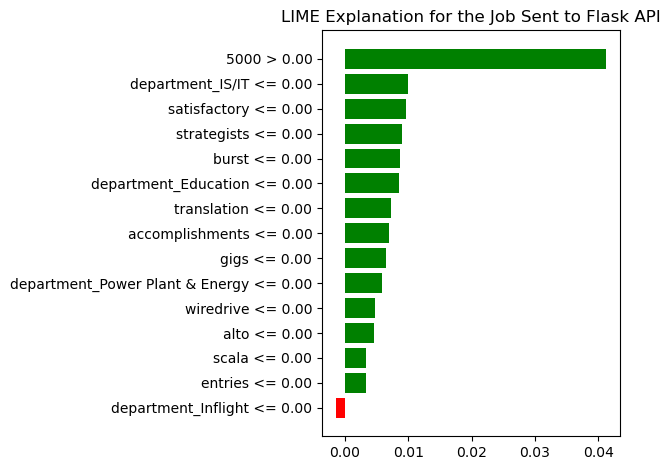

The model predicted this job posting as - Fake.
Red bars = Features supporting Real
Green bars = Features supporting Fake

Main reasons:
→ 5000 > 0.00   (supports Fake)
→ department_IS/IT <= 0.00   (supports Fake)
→ satisfactory <= 0.00   (supports Fake)
→ strategists <= 0.00   (supports Fake)
→ burst <= 0.00   (supports Fake)
→ department_Education <= 0.00   (supports Fake)
→ translation <= 0.00   (supports Fake)
→ accomplishments <= 0.00   (supports Fake)
→ gigs <= 0.00   (supports Fake)
→ department_Power Plant & Energy <= 0.00   (supports Fake)
→ wiredrive <= 0.00   (supports Fake)
→ alto <= 0.00   (supports Fake)
→ scala <= 0.00   (supports Fake)
→ entries <= 0.00   (supports Fake)
→ department_Inflight <= 0.00   (supports Real)

According to these important features and reasons, the model predicted this job posting as - Fake.


In [103]:
# Creating LIME explainer
X_train_dense = X_train[:1000].toarray()

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_dense,
    feature_names=vectorizer.get_feature_names_out().tolist() + \
                  encoder.get_feature_names_out(categorical_columns).tolist(),
    class_names=['Real', 'Fake'],
    mode='classification'
)

print('LIME Explainer is ready.\n')

# LIME Explanation for the same input
input_for_lime = new_job.copy()

for col in text_columns:
    input_for_lime[col] = text_clean(input_for_lime.get(col, 'unspecified'))

combined_text = ' '.join(input_for_lime[col] for col in text_columns)

X_text_new = vectorizer.transform([combined_text])
cat_df = pd.DataFrame({col: [input_for_lime.get(col, 'unspecified')] for col in categorical_columns})
X_cat_new = encoder.transform(cat_df)
X_new = hstack([X_text_new, X_cat_new]).toarray()[0]

# LIME Explanation
exp = explainer.explain_instance(
    X_new, 
    model.predict_proba, 
    num_features=15
)

# Show the LIME plot
exp.as_pyplot_figure()
plt.title(f'LIME Explanation for the Job Sent to Flask API')
plt.tight_layout()
plt.show()

# Simple text explanation 
print(f'The model predicted this job posting as - {result['prediction']}.')
print("Red bars = Features supporting Real")
print("Green bars = Features supporting Fake")
print("\nMain reasons:")

for feature, weight in exp.as_list():
    if weight > 0:
        print(f'→ {feature}   (supports Fake)') 
    else:
        print(f'→ {feature}   (supports Real)')

print(f"\nAccording to these important features and reasons, the model predicted this job posting as - {result['prediction']}.")